Explained Variance Ratio: [0.40662092 0.27577972]
Total Explained Variance: 0.6824006399224629


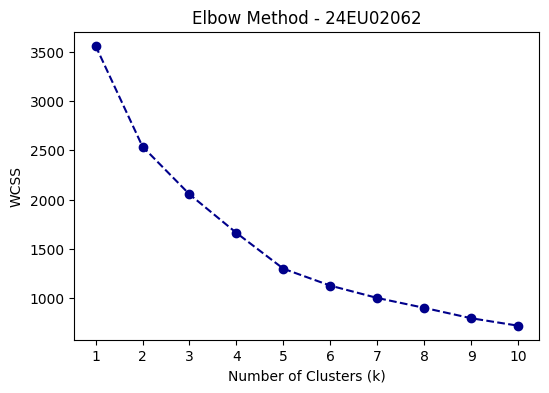

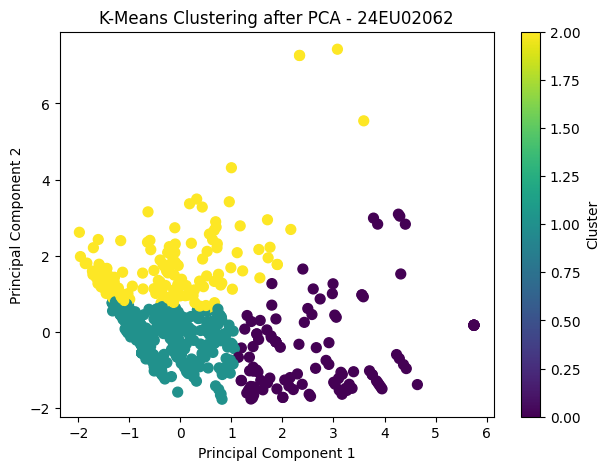

Silhouette Score: 0.5241
    Age     Fare  SibSp  Parch  Cluster
0  22.0   7.2500      1      0        1
1  38.0  71.2833      1      0        2
2  26.0   7.9250      0      0        1
3  35.0  53.1000      1      0        1
4  35.0   8.0500      0      0        1
5   NaN   8.4583      0      0        1
6  54.0  51.8625      0      0        2
7   2.0  21.0750      3      1        0
8  27.0  11.1333      0      2        1
9  14.0  30.0708      1      0        1


In [2]:
## Post Lab Task: Perform PCA and Clustering task on Titanic Dataset.##


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

X = df[['Age', 'Fare', 'SibSp', 'Parch']].copy()

X['Age'] = X['Age'].fillna(X['Age'].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method - 24EU02062")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(k_range)
plt.show()

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_pca.fit_predict(X_pca)

df['Cluster'] = clusters

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA - 24EU02062")
plt.colorbar(label="Cluster")
plt.show()

silhouette = silhouette_score(X_pca, clusters)
print("Silhouette Score:", round(silhouette, 4))

print(df[['Age', 'Fare', 'SibSp', 'Parch', 'Cluster']].head(10))